##Задача

* Найти данные в виде изображений для задачи классификации. Например, можно взять данные [отсюда](http://ufldl.stanford.edu/housenumbers/).
* Реализовать классы, необходимые для построения сети со следующими слоями
  * FullyConnectedLayer
  * ReluLayer
  * FullyConnectedLayer
* Использовать CrossEntropyLoss и L2-регуляризацию.
* Обучить модель на тренировочных данных, подбирать параметры (особенно learning rate) на валидационной и оценить качество на тестовой. Анализировать графики train/val loss, проверять на каждом шаге корректность вычисления градиентов с помощью разностной оценки.
 * (+2 балла) Добавить Batch normalization.
 * (+2 балла) В качестве оптимизатор использовать один из: Momentum, RMSprop.
 * (+1 балл) Также реализовать оптимизатор Adam.

## Датасет
Для задачи классификации возьмем предложенный датасет [The Street View House Numbers (SVHN) Dataset](http://ufldl.stanford.edu/housenumbers/). Каждая картинка 32х32 содержит номер дома, сфотографированный на улице.


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

print(torch.__version__)

2.10.0+cpu


**Загрузка датасета SVHN**

In [29]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.SVHN(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.SVHN(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

**DataLoader**

In [30]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [31]:
images, labels = next(iter(train_loader))
labels = labels % 10
print(images.shape)
print(labels[:10])
print(labels.unique())

torch.Size([64, 3, 32, 32])
tensor([4, 1, 2, 5, 2, 2, 4, 2, 7, 4])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


**Визуализация изображений**

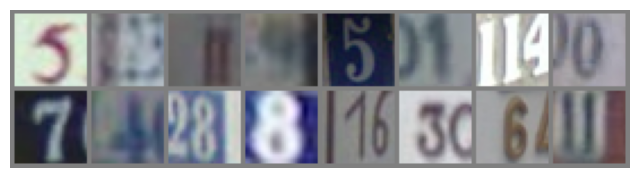

Labels: tensor([5, 2, 1, 9, 5, 1, 1, 0, 7, 4, 8, 8, 1, 3, 6, 1])


In [32]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(images, labels):
    images = images / 2 + 0.5
    npimg = images.numpy()

    plt.figure(figsize=(8, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

images, labels = next(iter(train_loader))
labels = labels % 10

show_batch(torchvision.utils.make_grid(images[:16]), labels[:16])
print("Labels:", labels[:16])

**Train / Validation split**

In [33]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])
train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_data,
    batch_size=64,
    shuffle=False
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)
print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_dataset))

Train: 58605
Val: 14652
Test: 26032


## Построение сети

`W` — веса \
`b` — смещение \
`nn.Parameter` — PyTorch будет считать градиенты \
`@` — матричное умножение

In [34]:
class FullyConnectedLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.W = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.b = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        return x @ self.W.t() + self.b

In [35]:
class ReluLayer(nn.Module):
    def forward(self, x):
        return torch.relu(x)

## Нейронная сеть с batch normalization

In [36]:
class SimpleNet(nn.Module):
    def __init__(self, use_bn=False):
        super().__init__()

        self.use_bn = use_bn
        self.flatten = nn.Flatten()

        self.fc1 = FullyConnectedLayer(3*32*32, 256)
        self.bn1 = nn.BatchNorm1d(256) if use_bn else None
        self.relu = ReluLayer()
        self.fc2 = FullyConnectedLayer(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        if self.use_bn:
            x = self.bn1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

## Оптимизатор Adam

In [37]:
class AdamOptimizer:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps

        self.m = {}
        self.v = {}
        self.t = 0

        for i, p in enumerate(self.params):
            self.m[i] = torch.zeros_like(p.data)
            self.v[i] = torch.zeros_like(p.data)

    def step(self):
        self.t += 1

        for i, p in enumerate(self.params):
            if p.grad is None:
                continue

            g = p.grad.data

            # moment 1
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g

            # moment 2
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g ** 2)

            # bias correction
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            # update
            p.data -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.data.zero_()

**Проверка градиентов с помощью разностной оценки**\
`model`: модель\
`inputs`: входные данные (один батч)\
`labels`: целевые метки\
`criterion`: функция потерь \
`eps`: шаг для численного дифференцирования

In [52]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def gradient_check(model, inputs, targets, criterion, eps=1e-3):
    model.eval()
    model.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()

    param_list = [param for param in model.parameters() if param.requires_grad]
    total_params = sum(p.numel() for p in param_list)
    num_checks = min(15, total_params)

    selected_indices = torch.randperm(total_params)[:num_checks]

    for param in param_list:
        param_data_flat = param.data.view(-1)
        param_grad_flat = param.grad.view(-1)

        for idx in selected_indices:
            if idx >= param_data_flat.size(0):
                break

            original_value = param_data_flat[idx].item()

            param_data_flat[idx] = original_value + eps
            loss_plus = criterion(model(inputs), targets).item()

            param_data_flat[idx] = original_value - eps
            loss_minus = criterion(model(inputs), targets).item()

            param_data_flat[idx] = original_value

            estimated_grad = (loss_plus - loss_minus) / (2 * eps)
            actual_grad = param_grad_flat[idx].item()

            if abs(estimated_grad - actual_grad) > eps:
                print(f"✗ Some gradient checks FAILED!")
                return

    print(f"✓ All gradient checks PASSED!")
    model.train()

## Train loop

In [39]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0

    for images, labels in loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

## Val loop

In [40]:
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

    acc = correct / len(loader.dataset)
    return total_loss / len(loader), acc

## Подбор learning rate и других параметров (модель, оптимизатор)

In [41]:
# Cross Entropy
criterion = nn.CrossEntropyLoss()

def run_training(model, optimizer):
  train_losses = []
  val_losses = []
  for epoch in range(10):
      train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
      val_loss, val_acc = evaluate(model, val_loader, criterion)

      sample_images, sample_labels = next(iter(train_loader))
      sample_images, sample_labels = sample_images[:8].to(device), sample_labels[:8].to(device)
      print(f"Gradient check at epoch {epoch+1}:")
      gradient_check(model, sample_images, sample_labels, criterion)

      train_losses.append(train_loss)
      val_losses.append(val_loss)

      print(f"Epoch {epoch+1}")
      print(f"train: {train_loss:.4f} | val: {val_loss:.4f} | acc: {val_acc:.4f}")
  return train_losses, val_losses


In [46]:
def plot_results(train_losses, val_losses):
  plt.plot(train_losses, label="train")
  plt.plot(val_losses, label="val")
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.title("Loss curves")
  plt.show()

In [43]:
def clear_results():
  train_losses = []
  val_losses = []
  val_accs = []

model: Batch normalization, optimizer: Adam, lr = 0.01
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 1.3139 | val: 1.0143 | acc: 0.6934
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.9654 | val: 0.9439 | acc: 0.7156
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.8612 | val: 0.8156 | acc: 0.7617
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.8103 | val: 0.7826 | acc: 0.7709
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.7582 | val: 0.7860 | acc: 0.7723
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.7326 | val: 0.7771 | acc: 0.7771
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.7138 | val: 0.7144 | acc: 0.7978
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.6884 | val: 0.6942 | acc: 0.8031
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.6737 | val: 0.6

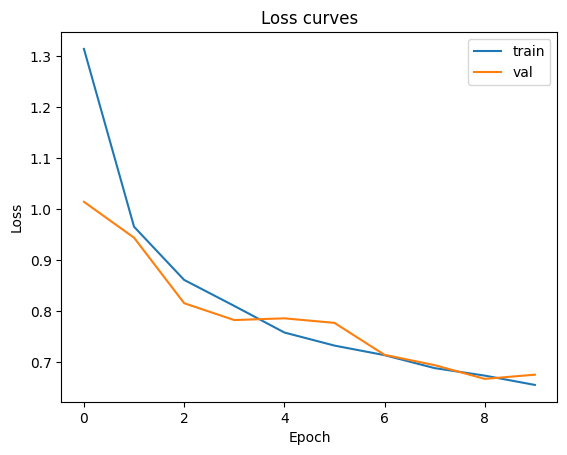

model: Batch normalization, optimizer: Momentum, lr = 0.01
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.5669 | val: 0.6166 | acc: 0.8303
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.5516 | val: 0.6115 | acc: 0.8332
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.5427 | val: 0.6044 | acc: 0.8346
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.5419 | val: 0.6014 | acc: 0.8339
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.5330 | val: 0.6018 | acc: 0.8352
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.5339 | val: 0.5968 | acc: 0.8363
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.5311 | val: 0.5968 | acc: 0.8357
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.5331 | val: 0.5963 | acc: 0.8343
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.5283 | val:

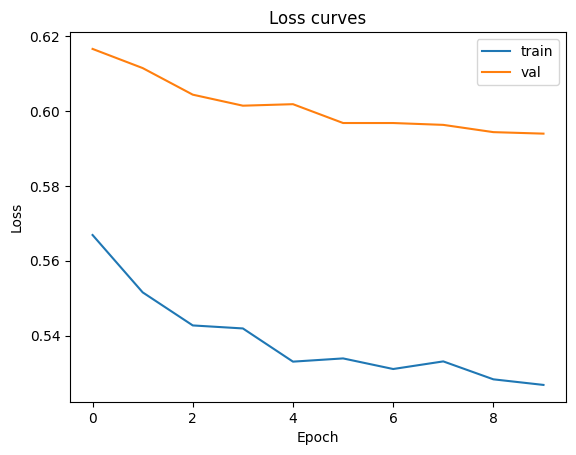

model: Simple, optimizer: Adam, lr = 0.01
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 2.4364 | val: 2.8228 | acc: 0.5569
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 2.2762 | val: 2.4702 | acc: 0.5986
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 2.1288 | val: 2.4204 | acc: 0.6200
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 2.0463 | val: 1.8260 | acc: 0.6527
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 2.3298 | val: 1.7231 | acc: 0.6707
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 1.9867 | val: 2.0694 | acc: 0.6686
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 2.3770 | val: 1.3325 | acc: 0.7157
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 1.8156 | val: 2.3697 | acc: 0.6615
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 1.9894 | val: 2.4918 | acc: 0.

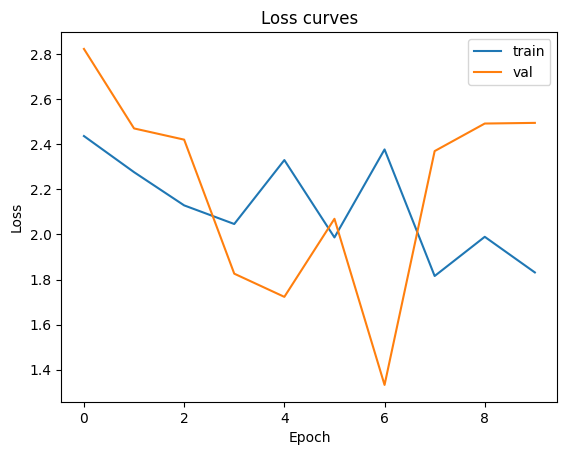

model: Simple, optimizer: Momentum, lr = 0.01
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 2.1273 | val: 2.2780 | acc: 0.7222
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 1.6909 | val: 2.0217 | acc: 0.7435
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 1.5597 | val: 1.9078 | acc: 0.7333
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 1.4513 | val: 1.7988 | acc: 0.7330
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 1.3133 | val: 1.7108 | acc: 0.7406
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 1.2429 | val: 1.7195 | acc: 0.7338
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 1.1607 | val: 1.5899 | acc: 0.7365
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 1.1589 | val: 1.4960 | acc: 0.7407
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 1.0765 | val: 1.5824 | acc

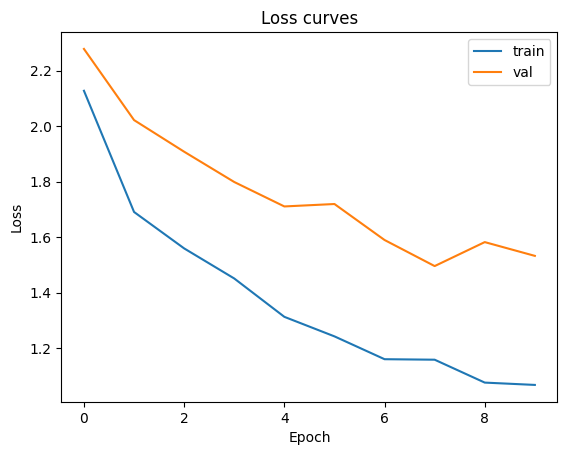

model: Batch normalization, optimizer: Adam, lr = 0.001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.5271 | val: 0.5897 | acc: 0.8376
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.5173 | val: 0.5869 | acc: 0.8402
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.5118 | val: 0.5797 | acc: 0.8430
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.5087 | val: 0.5773 | acc: 0.8434
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.5032 | val: 0.5831 | acc: 0.8441
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.4994 | val: 0.5819 | acc: 0.8436
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.4974 | val: 0.5852 | acc: 0.8415
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.4946 | val: 0.5767 | acc: 0.8456
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.4887 | val: 0.

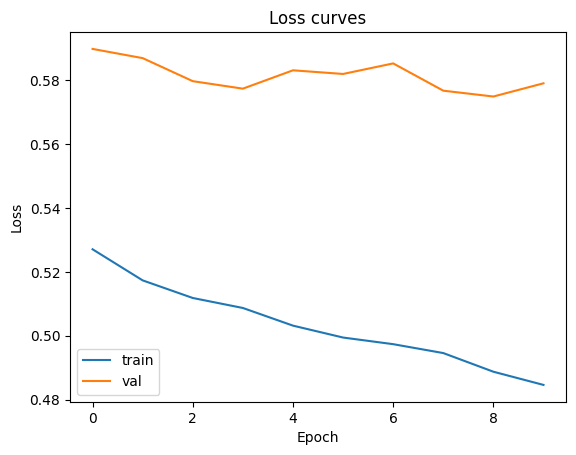

model: Batch normalization, optimizer: Momentum, lr = 0.001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.4737 | val: 0.5793 | acc: 0.8428
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.4719 | val: 0.5755 | acc: 0.8443
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.4743 | val: 0.5743 | acc: 0.8466
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.4685 | val: 0.5727 | acc: 0.8447
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.4726 | val: 0.5739 | acc: 0.8438
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.4702 | val: 0.5728 | acc: 0.8444
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.4735 | val: 0.5723 | acc: 0.8447
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.4680 | val: 0.5706 | acc: 0.8446
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.4724 | val

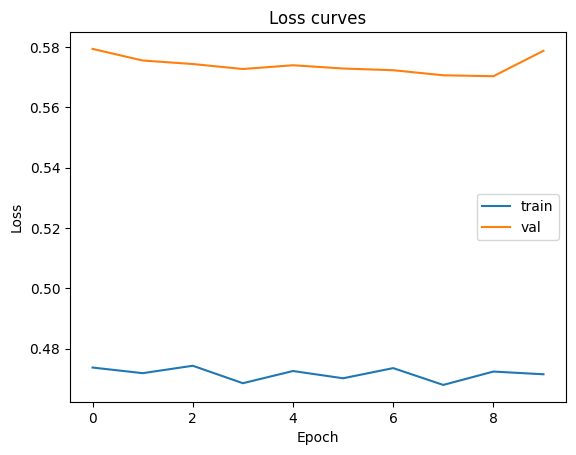

model: Simple, optimizer: Adam, lr = 0.001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.8870 | val: 1.1835 | acc: 0.7668
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.7387 | val: 1.0856 | acc: 0.7707
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.6715 | val: 1.0239 | acc: 0.7783
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.6303 | val: 0.9632 | acc: 0.7810
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.6049 | val: 0.9321 | acc: 0.7821
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.5822 | val: 0.8828 | acc: 0.7903
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.5704 | val: 0.8935 | acc: 0.7877
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.5590 | val: 0.8818 | acc: 0.7922
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.5486 | val: 0.8780 | acc: 0

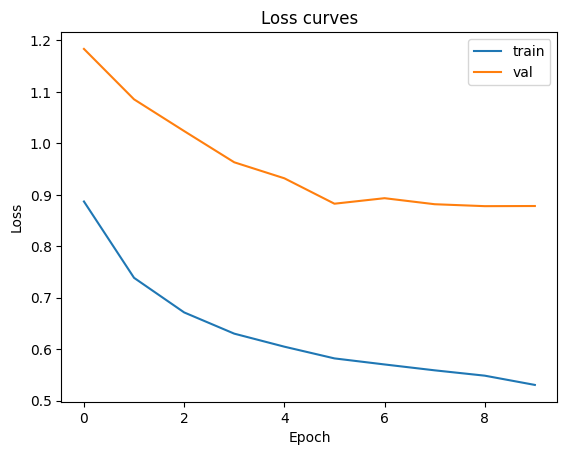

model: Simple, optimizer: Momentum, lr = 0.001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.4907 | val: 0.8481 | acc: 0.7970
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.4762 | val: 0.8396 | acc: 0.7976
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.4698 | val: 0.8365 | acc: 0.7987
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.4664 | val: 0.8322 | acc: 0.8003
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.4626 | val: 0.8362 | acc: 0.7993
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.4610 | val: 0.8351 | acc: 0.8005
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.4594 | val: 0.8430 | acc: 0.7968
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.4583 | val: 0.8364 | acc: 0.8006
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.4574 | val: 0.8394 | ac

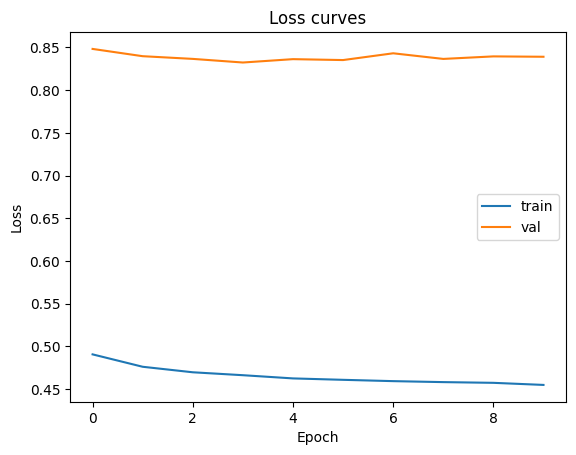

model: Batch normalization, optimizer: Adam, lr = 0.0001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.4698 | val: 0.5735 | acc: 0.8447
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.4701 | val: 0.5715 | acc: 0.8455
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.4686 | val: 0.5722 | acc: 0.8441
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.4722 | val: 0.5672 | acc: 0.8471
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.4683 | val: 0.5746 | acc: 0.8449
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.4665 | val: 0.5717 | acc: 0.8445
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.4682 | val: 0.5693 | acc: 0.8456
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.4698 | val: 0.5710 | acc: 0.8463
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.4668 | val: 0

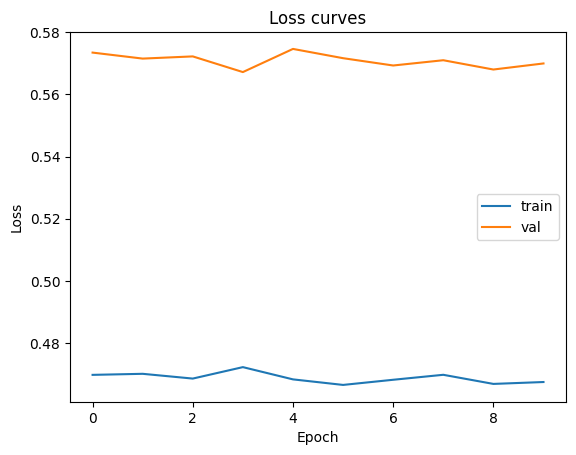

model: Batch normalization, optimizer: Momentum, lr = 0.0001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.4640 | val: 0.5710 | acc: 0.8453
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.4650 | val: 0.5715 | acc: 0.8464
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.4630 | val: 0.5718 | acc: 0.8458
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.4678 | val: 0.5695 | acc: 0.8448
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.4678 | val: 0.5693 | acc: 0.8471
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.4637 | val: 0.5677 | acc: 0.8466
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.4638 | val: 0.5703 | acc: 0.8448
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.4634 | val: 0.5745 | acc: 0.8450
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.4634 | va

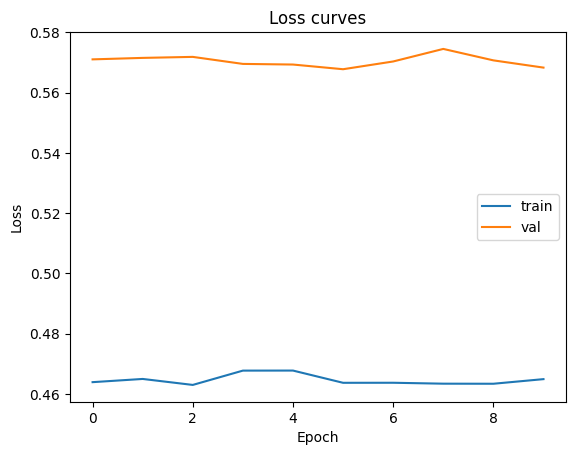

model: Simple, optimizer: Adam, lr = 0.0001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.4461 | val: 0.8308 | acc: 0.8032
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.4371 | val: 0.8347 | acc: 0.8024
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.4316 | val: 0.8329 | acc: 0.8033
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.4275 | val: 0.8380 | acc: 0.8031
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.4240 | val: 0.8450 | acc: 0.8038
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.4204 | val: 0.8447 | acc: 0.8032
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.4171 | val: 0.8457 | acc: 0.8018
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.4143 | val: 0.8511 | acc: 0.8025
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.4113 | val: 0.8519 | acc: 

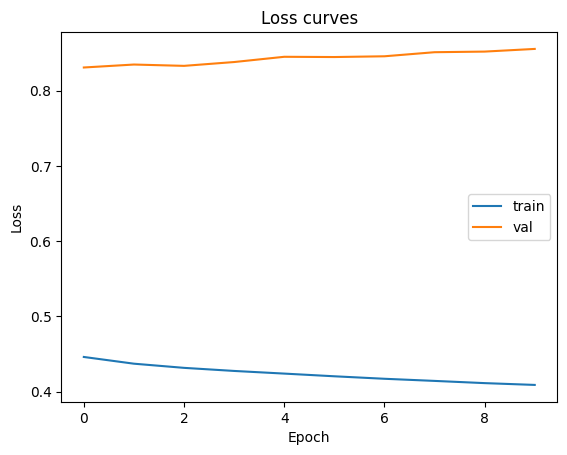

model: Simple, optimizer: Momentum, lr = 0.0001
Gradient check at epoch 1:
✓ All gradient checks PASSED!
Epoch 1
train: 0.4005 | val: 0.8551 | acc: 0.8025
Gradient check at epoch 2:
✓ All gradient checks PASSED!
Epoch 2
train: 0.4002 | val: 0.8550 | acc: 0.8044
Gradient check at epoch 3:
✓ All gradient checks PASSED!
Epoch 3
train: 0.3998 | val: 0.8554 | acc: 0.8032
Gradient check at epoch 4:
✓ All gradient checks PASSED!
Epoch 4
train: 0.3997 | val: 0.8556 | acc: 0.8038
Gradient check at epoch 5:
✓ All gradient checks PASSED!
Epoch 5
train: 0.3995 | val: 0.8561 | acc: 0.8029
Gradient check at epoch 6:
✓ All gradient checks PASSED!
Epoch 6
train: 0.3994 | val: 0.8562 | acc: 0.8038
Gradient check at epoch 7:
✓ All gradient checks PASSED!
Epoch 7
train: 0.3992 | val: 0.8565 | acc: 0.8034
Gradient check at epoch 8:
✓ All gradient checks PASSED!
Epoch 8
train: 0.3991 | val: 0.8563 | acc: 0.8038
Gradient check at epoch 9:
✓ All gradient checks PASSED!
Epoch 9
train: 0.3990 | val: 0.8567 | a

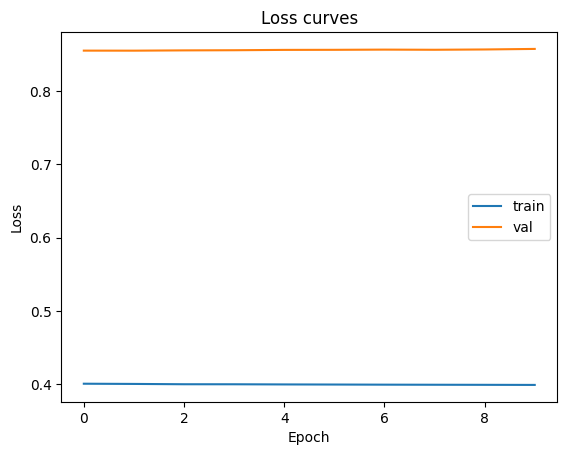

In [54]:
lrs = [1e-2, 1e-3, 1e-4]
models = [SimpleNet(use_bn=True), SimpleNet()]
models_print = ["Batch normalization", "Simple"]
for lr in lrs:
      opt_print = ["Adam", "Momentum"]
      for i in range(len(models)):
            model = models[i]
            optimizer_Adam = AdamOptimizer(model.parameters(), lr=lr)
            optimizer_SGD = torch.optim.SGD(
                model.parameters(),
                lr=lr,
                momentum=0.9,
                weight_decay=1e-4
            )
            optimizers = [optimizer_Adam, optimizer_SGD]
            for j in range(len(optimizers)):
                  print(f"model: {models_print[i]}, optimizer: {opt_print[j]}, lr = {lr}")
                  train_losses, val_losses = run_training(model, optimizers[j])
                  plot_results(train_losses, val_losses)


=> лучшие результаты с learning rate = 0.001, batch normalization и оптимизатором Momentum


In [55]:
model = SimpleNet(use_bn=True)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001,
    momentum=0.9,
    # L2-regularization
    weight_decay=1e-4
)
for epoch in range(10):
      train_one_epoch(model, test_loader, optimizer, criterion)
test_loss, test_acc = evaluate(model, test_loader, criterion)

print("TEST LOSS:", test_loss)
print("TEST ACC:", test_acc)

TEST LOSS: 0.7015816268376109
TEST ACC: 0.8130377996312231
